In [61]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

data_path = "../../datasets/airline_passengers/airline-passengers.csv"

In [62]:
data = pd.read_csv(data_path).to_numpy()

train_raw, test_raw = data[:120, -1], data[120:, -1]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
scaled_all = scaler.transform(data[:, -1].reshape(-1, 1)).flatten()



In [63]:
from numpy import float32


inputs = []
targets = []

for i in range(132):
    inputs.append(scaled_all[i:i+12])
    targets.append(scaled_all[i+12])

X, y = np.array(inputs), np.array(targets)

X = X[:, :, np.newaxis]

X, y = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

X_train, X_test = X[:108], X[108:]
y_train, y_test = y[:108], y[108:]


In [64]:
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.output = nn.Linear(50, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.output(out)

        return out



Loop(0): 0.18193548917770386
Loop(100): 0.011617784388363361
Loop(200): 0.008050138130784035
Loop(300): 0.005867610219866037
Loop(400): 0.002014752244576812


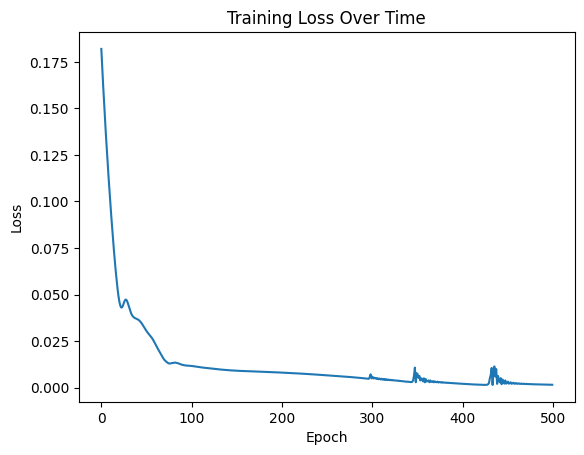

48.2302


In [65]:
model = LSTMModel()
model.train()


optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.MSELoss() 

loss_list = []

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())


    if epoch % 100 == 0:
        print(f"Loop({epoch}): {loss}")

plt.plot(loss_list)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

model.eval()

with torch.no_grad():
    outputs = model(X_test)
    y_actual, y_pred = scaler.inverse_transform(y_test.detach().numpy()), scaler.inverse_transform(outputs.detach().numpy())
    print(np.sqrt(np.mean((y_pred - y_actual)** 2)))


        

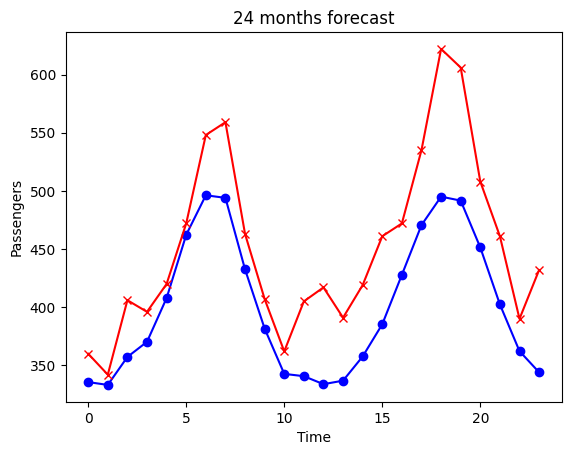

In [66]:
results = []
window = scaled_all[108:120]

for i in range(24):
    outputs = model(torch.tensor(window, dtype=torch.float32).reshape(1, 12, 1))
    results.append(outputs.detach().numpy().flatten()[0])
    window = np.append(window[1:], outputs.detach().numpy())

results = scaler.inverse_transform(np.array(results).reshape(-1, 1))
true = scaler.inverse_transform(np.array(scaled_all[120:]).reshape(-1, 1))

plt.plot(results, color='blue', marker='o', label='predictions')
plt.plot(true, color='red', marker='x', label='true')
plt.title('24 months forecast')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.show()
